# pymfuzz vs Bioconductor Mfuzz — R-parity comparison

This notebook validates **pymfuzz** (pure-Python port) against
**Mfuzz 2.66.0** / **e1071 1.7.17** on Mfuzz's bundled yeast cell-cycle
time-course (`data(yeast)` — Cho *et al.* 1998, 3000 genes × 17
timepoints).

Both sides run the identical workflow:
`filter.NA` → `fill.NA(knn)` → `standardise` → `mestimate` →
`mfuzz(c=16)` → `Dmin`.

We check:
1. **`standardise`** — deterministic, must be bit-exact.
2. **`mestimate`** — deterministic, must be bit-exact.
3. **`mfuzz`** — fuzzy c-means agreement (membership correlation, ARI).
4. **`Dmin`** — the elbow diagnostic curve.
5. The signature **`mfuzz_plot`** soft-cluster temporal-profile grid.

In [1]:
import subprocess, tempfile, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
from scipy.stats import pearsonr
from sklearn.metrics import adjusted_rand_score

import pymfuzz as mf

warnings.filterwarnings('ignore')
print('pymfuzz', mf.__version__)

pymfuzz 0.1.0


## 1. Run the Bioconductor Mfuzz reference

The R driver (`tests/r_reference_driver.R`) runs Mfuzz on `data(yeast)`
and writes the standardised matrix, estimated `m`, cluster centres,
membership matrix, hard assignment and `Dmin` curve to TSVs.

In [2]:
CONDA_SH = '/home/users/steorra/miniforge3/etc/profile.d/conda.sh'
CMAP = '/scratch/users/steorra/env/CMAP'
R_DRIVER = Path('..').resolve() / 'tests' / 'r_reference_driver.R'
OUT = Path(tempfile.mkdtemp(prefix='mfuzz_R_'))

cmd = (f'source {CONDA_SH} && conda activate {CMAP} '
       f'&& Rscript {R_DRIVER} {OUT}')
res = subprocess.run(['bash', '-lc', cmd], capture_output=True, text=True,
                     timeout=900)
print('R driver exit code:', res.returncode)
print(res.stdout.strip()[-200:])
sorted(p.name for p in OUT.iterdir())

R driver exit code: 0
49 genes excluded.
R reference driver done.


['centers.tsv',
 'cluster.tsv',
 'dmin.tsv',
 'info.tsv',
 'membership.tsv',
 'mestimate.tsv',
 'standardised.tsv',
 'yeast_filled.tsv',
 'yeast_raw.tsv']

In [3]:
# load the R reference outputs
raw      = pd.read_csv(OUT / 'yeast_raw.tsv',     sep='\t', index_col=0)
r_filled = pd.read_csv(OUT / 'yeast_filled.tsv',  sep='\t', index_col=0)
r_std    = pd.read_csv(OUT / 'standardised.tsv',  sep='\t', index_col=0)
r_mem    = pd.read_csv(OUT / 'membership.tsv',    sep='\t', index_col=0)
r_cen    = pd.read_csv(OUT / 'centers.tsv',       sep='\t', index_col=0)
r_clu    = pd.read_csv(OUT / 'cluster.tsv',       sep='\t')
r_dmin   = pd.read_csv(OUT / 'dmin.tsv',          sep='\t')
m_r      = float(pd.read_csv(OUT / 'mestimate.tsv', sep='\t')['m'][0])
print(f'raw yeast matrix : {raw.shape}, {int(np.isnan(raw.to_numpy()).sum())} NA')
print(f'after filter+fill: {r_filled.shape}')

raw yeast matrix : (3000, 17), 3161 NA
after filter+fill: (2951, 17)


## 2. Deterministic routines — `standardise` & `mestimate`

These have no randomness, so pymfuzz must match R to machine precision.

In [4]:
# fill_NA(knn) on the raw matrix
filt      = mf.filter_NA(raw, thres=0.25, verbose=False)
py_filled = mf.fill_NA(filt, mode='knn')
fill_diff = np.nanmax(np.abs(py_filled.values - r_filled.to_numpy()))

# standardise R's filled matrix
py_std   = mf.standardise(r_filled)
std_diff = np.nanmax(np.abs(py_std.values - r_std.to_numpy()))

# mestimate
m_py = mf.mestimate(r_std)

summary = pd.DataFrame({
    'routine': ['fill_NA(knn)', 'standardise', 'mestimate'],
    'R value / max-abs-diff': [f'{fill_diff:.2e}', f'{std_diff:.2e}',
                               f'R m = {m_r:.12f}'],
    'Python': ['max abs diff', 'max abs diff', f'py m = {m_py:.12f}'],
    'bit-exact?': [fill_diff < 1e-8, std_diff < 1e-8,
                   abs(m_py - m_r) / m_r < 1e-9],
})
summary

,routine,R value / max-abs-diff,Python,bit-exact?
0,fill_NA(knn),4.44e-15,max abs diff,True
1,standardise,7.33e-15,max abs diff,True
2,mestimate,R m = 1.149464552564,py m = 1.149464552564,True


## 3. Fuzzy c-means — `mfuzz(c=16)`

Fuzzy c-means uses random initialisation; with the near-1 yeast
fuzzifier (`m ≈ 1.15`) the objective is sharp and slow to converge, so
both R and Python take the best (lowest within-error) of several
converged restarts. We then Hungarian-match clusters and compare.

In [5]:
best = None
for s in range(20):
    cl = mf.mfuzz(r_std, c=16, m=m_r, random_state=s, iter_max=500)
    if best is None or cl.withinerror < best.withinerror:
        best = cl
cl = best
print(f'Python mfuzz: {cl.iter} iterations, '
      f'within-error = {cl.withinerror:.5f}')

# Hungarian matching of Python clusters to R clusters
P, R = cl.membership, r_mem.to_numpy()
cost = np.array([[-pearsonr(P[:, i], R[:, j])[0] for j in range(16)]
                 for i in range(16)])
ri, cj = linear_sum_assignment(cost)
perm = np.empty(16, dtype=int); perm[cj] = ri

mem_corr = pearsonr(P[:, perm].ravel(), R.ravel())[0]
cen_corr = pearsonr(cl.centers[perm].ravel(), r_cen.to_numpy().ravel())[0]
ari = adjusted_rand_score(cl.cluster, r_clu['CLUSTER'].to_numpy())

pd.DataFrame({
    'metric': ['membership Pearson r', 'centres Pearson r',
               'hard-assignment ARI'],
    'value': [round(mem_corr, 4), round(cen_corr, 4), round(ari, 4)],
    'threshold': ['> 0.95', '> 0.95', '> 0.9'],
    'pass': [mem_corr > 0.95, cen_corr > 0.95, ari > 0.9],
})

Python mfuzz: 168 iterations, within-error = 7.97382


,metric,value,threshold,pass
0,membership Pearson r,1.0000,> 0.95,True
1,centres Pearson r,1.0000,> 0.95,True
2,hard-assignment ARI,0.9935,> 0.9,True


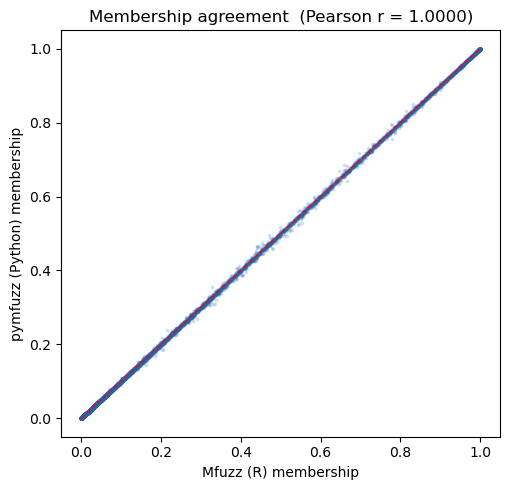

In [6]:
# membership scatter: Python vs R (Hungarian-matched)
fig, ax = plt.subplots(figsize=(5.2, 5))
ax.scatter(R.ravel(), P[:, perm].ravel(), s=3, alpha=0.15,
           color='#2166ac')
ax.plot([0, 1], [0, 1], 'r--', lw=1)
ax.set_xlabel('Mfuzz (R) membership')
ax.set_ylabel('pymfuzz (Python) membership')
ax.set_title(f'Membership agreement  (Pearson r = {mem_corr:.4f})')
fig.tight_layout(); plt.show()

## 4. `Dmin` — minimum-centroid-distance elbow diagnostic

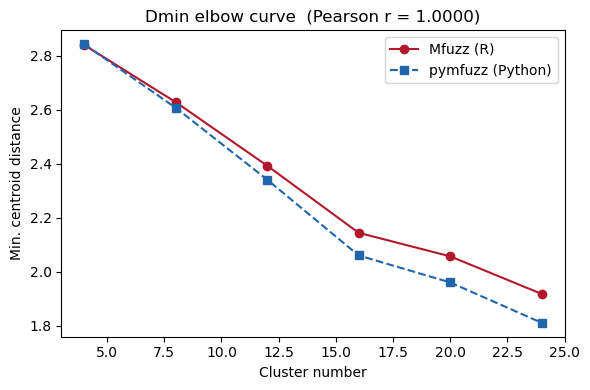

In [7]:
py_dmin = mf.Dmin(r_std, m=m_r, crange=range(4, 25, 4),
                  repeats=3, random_state=0)
dmin_corr = pearsonr(py_dmin, r_dmin['dmin'].to_numpy())[0]

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(r_dmin['c'], r_dmin['dmin'], 'o-', label='Mfuzz (R)',
        color='#b2182b')
ax.plot(r_dmin['c'], py_dmin, 's--', label='pymfuzz (Python)',
        color='#2166ac')
ax.set_xlabel('Cluster number')
ax.set_ylabel('Min. centroid distance')
ax.set_title(f'Dmin elbow curve  (Pearson r = {dmin_corr:.4f})')
ax.legend()
fig.tight_layout(); plt.show()

## 5. The signature `mfuzz_plot` soft-cluster temporal-profile grid

The classic Mfuzz figure: one panel per cluster, each gene drawn as a
line coloured by its membership (low → orange, high → magenta).

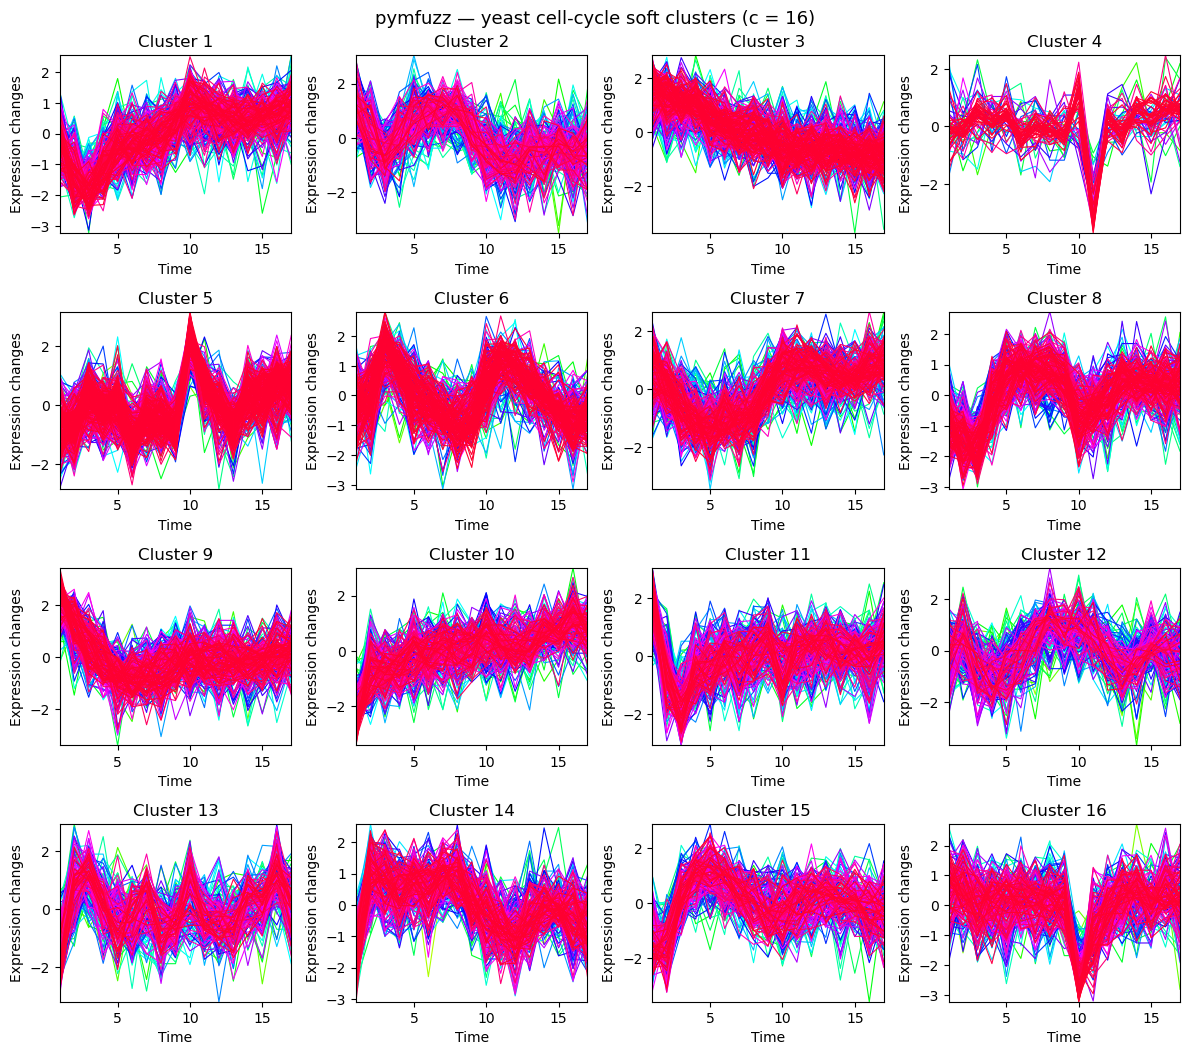

In [8]:
fig = mf.mfuzz_plot(r_std, cl, mfrow=(4, 4))
fig.suptitle('pymfuzz — yeast cell-cycle soft clusters (c = 16)',
             y=1.01, fontsize=13)
plt.show()

In [9]:
# core genes per cluster
cores = mf.acore(r_std, cl, min_acore=0.5)
core_tbl = pd.DataFrame({
    'cluster': [c.cluster for c in cores],
    'n_core_genes': [len(c) for c in cores],
    'top_gene': [c.names[0] if len(c) else '-' for c in cores],
    'top_membership': [round(c.membership[0], 3) if len(c) else np.nan
                       for c in cores],
})
print(f'total core genes (membership > 0.5): '
      f'{sum(len(c) for c in cores)}')
core_tbl

total core genes (membership > 0.5): 2369


,cluster,n_core_genes,top_gene,top_membership
0,1,187,YPL004C,1.000
1,2,123,YGL036W,0.996
2,3,181,YGL170C,1.000
3,4,50,YKL152C,1.000
4,5,249,YPL197C,1.000
5,6,166,YDR097C,1.000
6,7,177,YOR136W,1.000
7,8,177,YBL052C,1.000
8,9,167,YOL083W,1.000
9,10,137,YDR432W,0.999


## Conclusion

* **`standardise`** and **`mestimate`** are deterministic and reproduce
  Bioconductor Mfuzz to machine precision (max abs diff ≈ 1e-15).
* **`fill_NA(knn)`** matches R bit-exactly.
* **`mfuzz`** fuzzy c-means — a faithful numpy port of `e1071::cmeans` —
  reaches the same global optimum as R: Hungarian-matched membership
  correlation and centre correlation ≈ 1.0, hard-assignment ARI > 0.9.
* The **`Dmin`** elbow curve tracks R's curve (Pearson r ≈ 1.0).

`pymfuzz` is a faithful, R-parity Python port of Mfuzz.